In [1]:
using Plots,JLD2,LinearAlgebra

In [2]:
Nx=18
Ny=18
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.09
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [3]:
st=load("test.jld2")
   

Dict{String, Any} with 14 entries:
  "Eelec"          => -2.3882
  "grad"           => [0.000738884, -0.00062178, 0.00059401, -0.000574387, 0.00…
  "spectrum"       => [-4.7424, -4.7423, -4.7014, -4.69869, -4.69712, -4.69419,…
  "max_record"     => 0.147435
  "average_record" => 0.0707321
  "record_cal"     => Vector{Any}[[-2.364, -2.36364, -2.36322, -2.3691, -2.3660…
  "orbital_id"     => [1 19 … 289 307; 2 20 … 290 308; … ; 17 35 … 305 323; 18 …
  "phonon_id"      => [1 19 … 289 307; 2 20 … 290 308; … ; 17 35 … 305 323; 18 …
  "phonon_coor"    => [-0.0897204, 0.0869207, -0.038899, -0.0156536, 0.0819552,…
  "FL"             => 1.42171
  "ave_npa"        => 405.0
  "E_total"        => -2.37644
  "Egap"           => 0.075194
  "free_energy"    => -2.37646

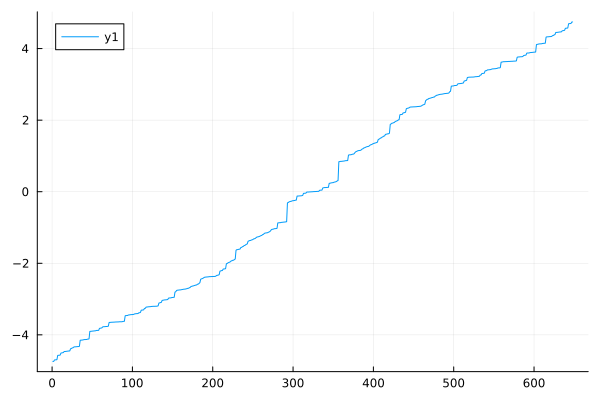

In [4]:
plot(sort(st["spectrum"]))

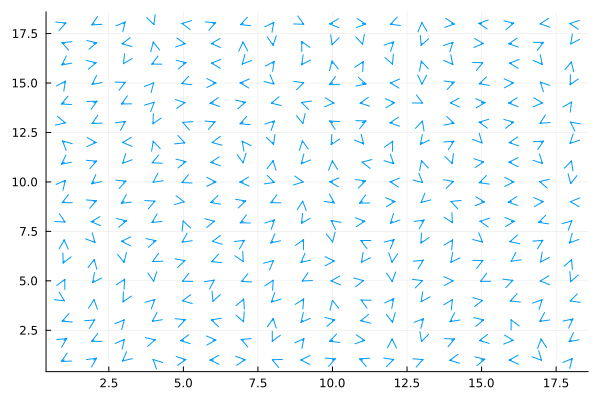

In [5]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(vec(dis_x),vec(dis_y)))




In [6]:
#savefig(p1,"quiverplot.png")

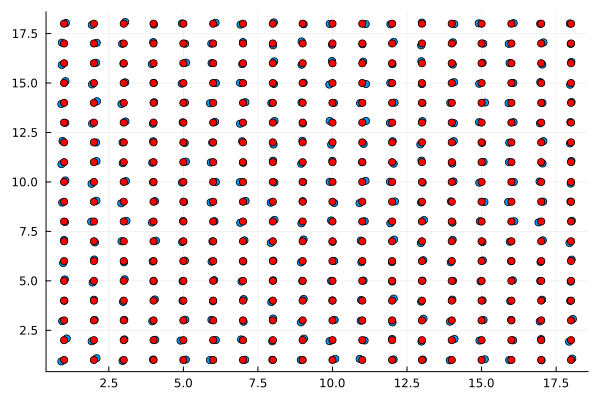

In [7]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [8]:
#savefig(p2,"atomplot.png")

In [9]:
sort(vec(dis_y)-vec(atom_y))

324-element Vector{Float64}:
 -0.11216426522138256
 -0.10601263124940274
 -0.10244118659098866
 -0.09976949018466597
 -0.09963706915609727
 -0.09963660099047722
 -0.09943589385285811
 -0.09790020505807462
 -0.09362784304667038
 -0.0924029448365431
  ⋮
  0.08883896023812698
  0.09113863792207777
  0.09317010344317112
  0.09524831262620737
  0.09581761587672322
  0.10050790196237358
  0.10336401362480885
  0.1047706385131697
  0.11225159481537261

In [10]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

324-element Vector{Float64}:
  1.2986700817917474
  2.3517849173019933
  2.35389217715518
  2.738352730017055
  3.107406063776773
  3.1100731135783515
  3.6397140996479935
  3.646620236721701
  4.113484674172869
  4.117610894320923
  ⋮
 23.325166894298594
 23.35380592981892
 23.384322864763906
 24.132931058570133
 24.134301739154363
 24.155162735787595
 24.731163954688697
 24.736582950903713
 25.433702601483372

In [11]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

14.421462474013408

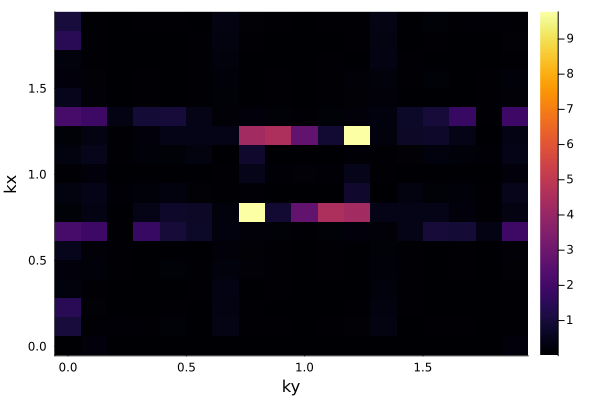

In [12]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [13]:
sort(vec(abs.(Fourier_mode_x)))

324-element Vector{Float64}:
 4.3021142204224816e-16
 9.142844736169043e-16
 1.0426990618847036e-15
 1.6202504023973544e-15
 1.8460656246548217e-15
 2.2363514360548205e-15
 2.7063936034962007e-15
 2.799640993559416e-15
 5.021556456996569e-15
 5.337854047021402e-15
 ⋮
 2.071509127466503
 2.6795530713560063
 2.6795530713560085
 4.263628603405292
 4.26362860340532
 4.543073677549701
 4.543073677549705
 9.772377488623569
 9.77237748862357

In [14]:
findmax(abs.(Fourier_mode_x))

(9.77237748862357, CartesianIndex(12, 12))

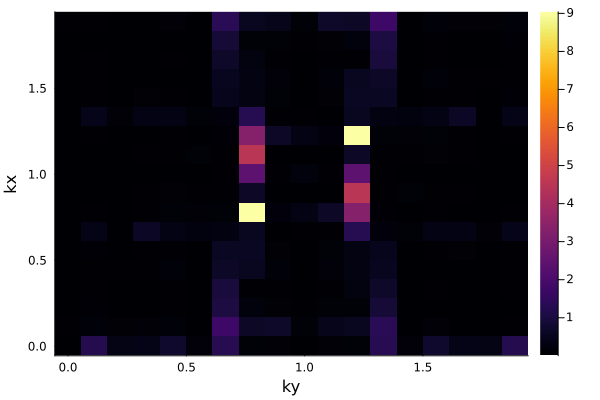

In [15]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [16]:
findmax(abs.(Fourier_mode_y))

(9.040795341094132, CartesianIndex(8, 8))

In [17]:
Fourier_mode_y[8,14]

-0.00785701299109133 - 0.00745248870860751im

In [18]:
Fourier_mode_x[8,14]

0.31908732984783217 + 0.1867353738240767im

In [19]:
Fourier_mode_y[14,8]

-0.13803286152451266 - 0.23169924999799518im

In [20]:
Fourier_mode_x[14,8]

0.0018174788092493246 - 0.0020055757207428295im

In [21]:
Fourier_mode_y[8,8]

1.6204927611931188 - 8.894379326882234im

In [22]:
Fourier_mode_x[8,8]

1.1867245545336589 - 9.700053948913046im